In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("dragonheir/logistic-regression")

print("Path to dataset files:", path)

/opt/homebrew/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /Users/ethanhersch/.cache/kagglehub/datasets/dragonheir/logistic-regression/versions/1


In [2]:
import os
import pandas as pd
import torch
import numpy as np
import matplotlib.pyplot as plt
#df = pd.read_csv('data.csv')

In [3]:
file_path = os.path.join(path, "Social_Network_Ads.csv")
df = pd.read_csv(file_path)

In [4]:
df.head()
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,1,19,19000,0
1,15810944,1,35,20000,0
2,15668575,0,26,43000,0
3,15603246,0,27,57000,0
4,15804002,1,19,76000,0


In [5]:
# Use double brackets for multiple columns
X = df[['Gender', 'Age', 'EstimatedSalary']].to_numpy()
X

array([[    1,    19, 19000],
       [    1,    35, 20000],
       [    0,    26, 43000],
       ...,
       [    0,    50, 20000],
       [    1,    36, 33000],
       [    0,    49, 36000]], shape=(400, 3))

In [6]:
new_X = np.hstack((X, np.ones((400, 1))))
# Stack 1s
new_X

array([[1.0e+00, 1.9e+01, 1.9e+04, 1.0e+00],
       [1.0e+00, 3.5e+01, 2.0e+04, 1.0e+00],
       [0.0e+00, 2.6e+01, 4.3e+04, 1.0e+00],
       ...,
       [0.0e+00, 5.0e+01, 2.0e+04, 1.0e+00],
       [1.0e+00, 3.6e+01, 3.3e+04, 1.0e+00],
       [0.0e+00, 4.9e+01, 3.6e+04, 1.0e+00]], shape=(400, 4))

In [7]:
Y = df['Purchased'].to_numpy()
Y

array([0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1,
       0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0,
       1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0,
       1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1,

## What is logistic regression?

$$y = \sigma(w^Tx + b) = \frac{1}{1 + exp(-w^Tx + b)}$$

In [8]:
def sigmoid(x):
  x = np.array(x)
  return 1 / (1 + np.exp(-x))

In [9]:
sigmoid(torch.tensor([1,0,0]))

/var/folders/dv/3rt9dzq92qq4mwb8qz5mh_cw0000gn/T/ipykernel_61163/1323104762.py:2: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  x = np.array(x)


array([0.73105858, 0.5       , 0.5       ])

## What's the loss?

Using MLE, want to minimize the binary cross entropy loss

$$\mathcal{L}(w, b) = \frac{1}{N} \sum_{i=1}^N y_i \log(p(y_i)) + (1 - y_i) \log(1 - p(y_i))$$
$$ = \frac{1}{N} \sum_{i=1}^N y_i \log(\sigma(w^Tx_i + b)) + (1 - y_i) \log(1 - \sigma(w^Tx_i + b))$$

We will use the trick to stack $w$ and $b$ and stack a $1$ below $x_i$ to get

$$\mathcal{L}(w) = \frac{1}{N} \sum_{i=1}^N y_i \log(\sigma(w^Tx_i)) + (1 - y_i) \log(1 - \sigma(w^Tx_i))$$

$$\nabla_w [\frac{1}{N} \sum_{i=1}^N y_i \log(\sigma(w^Tx_i + b)) + (1 - y_i) \log(1 - \sigma(w^Tx_i + b))] = \frac{1}{N} \sum_{i=1}^N y_i \frac{1}{\sigma(w^Tx_i + b)} \sigma'(w^Tx_i + b) + (1 - y_i) \frac{1}{1 - \sigma(w^Tx_i + b)} (-\sigma'(w^Tx_i + b))$$

$$= \frac{1}{N} \sum_{i=1}^N y_i \frac{1}{\sigma(w^Tx_i + b)} \sigma(w^Tx_i + b)(1 - \sigma(w^Tx_i + b))(x_i) + (1 - y_i) \frac{1}{1 - \sigma(w^Tx_i + b)} (-\sigma(w^Tx_i + b)(1 - \sigma(w^Tx_i + b))(x_i))$$

(referring to the stacked $w$)

$$\nabla_w \mathcal{L}(w) = \frac{1}{N} \sum_{i=1}^N y_i (1 - \sigma(w^Tx_i))(x_i) - (1 - y_i) \sigma(w^Tx_i)(x_i)$$

Take one step in this direction with SGD

Make a simplification: $-(y_i (1 - p_i) x_i - (1 - y_i) p_i x_i) = -x_i(y_i - y_ip_i - p_i + y_ip_i) = x_i(p_i - y_i)$


In [10]:
X = X.astype(np.float64)
# Normalize X
X[:, 1:3] = (X[:, 1:3] - X[:, 1:3].mean(axis=0)) / X[:, 1:3].std(axis=0)
new_X = np.hstack((X, np.ones((X.shape[0], 1)))) # stack a column of 1s
w = np.random.randn(new_X.shape[1]) # make the weights small

In [11]:
def eval(w, X, Y):
  preds = sigmoid(w @ X.T)
  pred_labels = (preds >= 0.5).astype(int)
  return np.sum(pred_labels==Y) / len(Y)

In [12]:
n, d = new_X.shape
lr = 1e-2
loss_history = []
acc_history = []

for epoch in range(100):
    epoch_loss = 0.0

    for i in range(n):
        x_i = new_X[i]
        y_i = Y[i]

        pred = sigmoid(np.dot(x_i, w))
        grad = -(y_i * (1 - pred) * x_i - (1 - y_i) * pred * x_i)
        # alternatively
        # grad = (pred - y_i)* x_i
        loss = -(y_i * np.log(pred) + (1 - y_i) * np.log(1 - pred))

        epoch_loss += loss
        w -= lr * grad

    # average loss
    avg_loss = epoch_loss / n
    loss_history.append(avg_loss)

    acc = eval(w, new_X, Y)
    acc_history.append(acc)

    print(f'epoch {epoch}: loss={avg_loss:.4f}, acc={acc:.4f}')

epoch 0: loss=0.5535, acc=0.8150
epoch 1: loss=0.4260, acc=0.8275
epoch 2: loss=0.3907, acc=0.8350
epoch 3: loss=0.3752, acc=0.8425
epoch 4: loss=0.3668, acc=0.8525
epoch 5: loss=0.3615, acc=0.8500
epoch 6: loss=0.3580, acc=0.8500
epoch 7: loss=0.3555, acc=0.8525
epoch 8: loss=0.3537, acc=0.8500
epoch 9: loss=0.3523, acc=0.8550
epoch 10: loss=0.3512, acc=0.8550
epoch 11: loss=0.3503, acc=0.8550
epoch 12: loss=0.3497, acc=0.8525
epoch 13: loss=0.3491, acc=0.8525
epoch 14: loss=0.3486, acc=0.8525
epoch 15: loss=0.3483, acc=0.8525
epoch 16: loss=0.3479, acc=0.8525
epoch 17: loss=0.3477, acc=0.8525
epoch 18: loss=0.3475, acc=0.8525
epoch 19: loss=0.3473, acc=0.8525
epoch 20: loss=0.3471, acc=0.8525
epoch 21: loss=0.3470, acc=0.8550
epoch 22: loss=0.3469, acc=0.8550
epoch 23: loss=0.3468, acc=0.8550
epoch 24: loss=0.3467, acc=0.8550
epoch 25: loss=0.3466, acc=0.8525
epoch 26: loss=0.3465, acc=0.8525
epoch 27: loss=0.3465, acc=0.8525
epoch 28: loss=0.3464, acc=0.8525
epoch 29: loss=0.3464, a

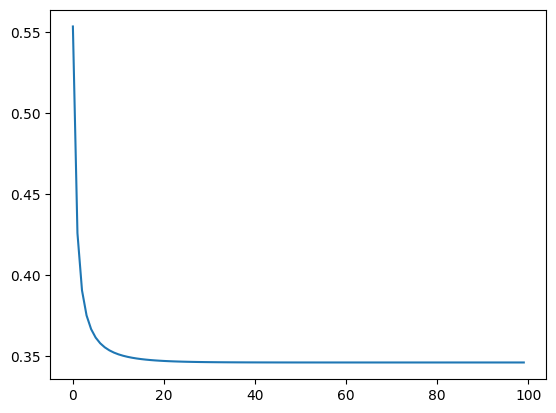

In [13]:
plt.plot(loss_history)

## Simple visual on toy 1-D dataset

In [14]:
# 1D feature
toy_X = np.array([
    [-4],
    [-3],
    [-2],
    [-1],
    [0],
    [1],
    [2],
    [3],
    [4],
    [5]
], dtype=np.float64)

# Labels
toy_Y = np.array([
    0, 0, 0, 0, 0,
    1, 1, 1, 1, 1
], dtype=np.float64)

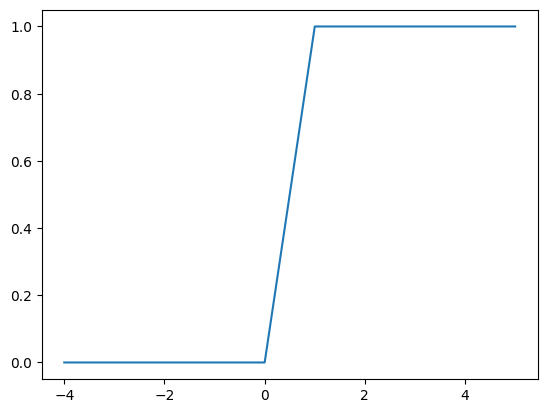

In [15]:
plt.plot(toy_X, toy_Y)
plt.show()

In [18]:
toy_X = toy_X.astype(np.float64)
# Normalize X
toy_X = np.hstack((toy_X, np.ones((toy_X.shape[0], 1)))) # stack a column of 1s
toy_w = np.random.randn(toy_X.shape[1]) # make the weights small

n, d = toy_X.shape
lr = 1e-2
loss_history = []
acc_history = []

for epoch in range(100):
    epoch_loss = 0.0

    for i in range(n):
        x_i = toy_X[i]
        y_i = toy_Y[i]

        pred = sigmoid(np.dot(x_i, toy_w))
        grad = -(y_i * (1 - pred) * x_i - (1 - y_i) * pred * x_i)
        # alternatively
        # grad = (pred - y_i)* x_i
        loss = -(y_i * np.log(pred) + (1 - y_i) * np.log(1 - pred))

        epoch_loss += loss
        toy_w -= lr * grad

    # average loss
    avg_loss = epoch_loss / n
    loss_history.append(avg_loss)

    acc = eval(toy_w, toy_X, toy_Y)
    acc_history.append(acc)

    print(f'epoch {epoch}: loss={avg_loss:.4f}, acc={acc:.4f}')

epoch 0: loss=0.6229, acc=0.9000
epoch 1: loss=0.5137, acc=0.9000
epoch 2: loss=0.4405, acc=1.0000
epoch 3: loss=0.3892, acc=1.0000
epoch 4: loss=0.3516, acc=1.0000
epoch 5: loss=0.3228, acc=1.0000
epoch 6: loss=0.3002, acc=1.0000
epoch 7: loss=0.2819, acc=1.0000
epoch 8: loss=0.2667, acc=1.0000
epoch 9: loss=0.2538, acc=1.0000
epoch 10: loss=0.2428, acc=1.0000
epoch 11: loss=0.2333, acc=1.0000
epoch 12: loss=0.2249, acc=1.0000
epoch 13: loss=0.2175, acc=1.0000
epoch 14: loss=0.2108, acc=1.0000
epoch 15: loss=0.2048, acc=1.0000
epoch 16: loss=0.1994, acc=1.0000
epoch 17: loss=0.1944, acc=1.0000
epoch 18: loss=0.1898, acc=1.0000
epoch 19: loss=0.1856, acc=1.0000
epoch 20: loss=0.1817, acc=1.0000
epoch 21: loss=0.1781, acc=1.0000
epoch 22: loss=0.1747, acc=1.0000
epoch 23: loss=0.1715, acc=1.0000
epoch 24: loss=0.1685, acc=1.0000
epoch 25: loss=0.1657, acc=1.0000
epoch 26: loss=0.1631, acc=1.0000
epoch 27: loss=0.1606, acc=1.0000
epoch 28: loss=0.1582, acc=1.0000
epoch 29: loss=0.1560, a

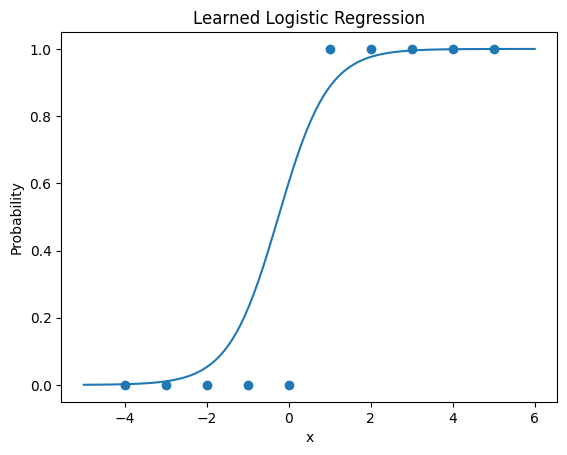

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# Recover original feature column (remove bias column)
X_plot = toy_X[:, 0]

# Generate smooth x values
x = np.linspace(X_plot.min() - 1, X_plot.max() + 1, 200)

# Compute learned sigmoid
y = sigmoid(toy_w[0] * x + toy_w[1])

# Plot data points
plt.scatter(X_plot, toy_Y)

# Plot learned curve
plt.plot(x, y)

plt.xlabel("x")
plt.ylabel("Probability")
plt.title("Learned Logistic Regression")
plt.show()